https://www.kaggle.com/datasets/shriyashjagtap/indian-personal-finance-and-spending-habits
link-with-this-dataset

In [2]:
!pip install shap xgboost -q

In [40]:
import shap
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize JS visualization in notebooks
shap.initjs()

In [11]:
url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
df = pd.read_csv(url)
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [12]:
df.shape

(768, 9)

<Axes: >

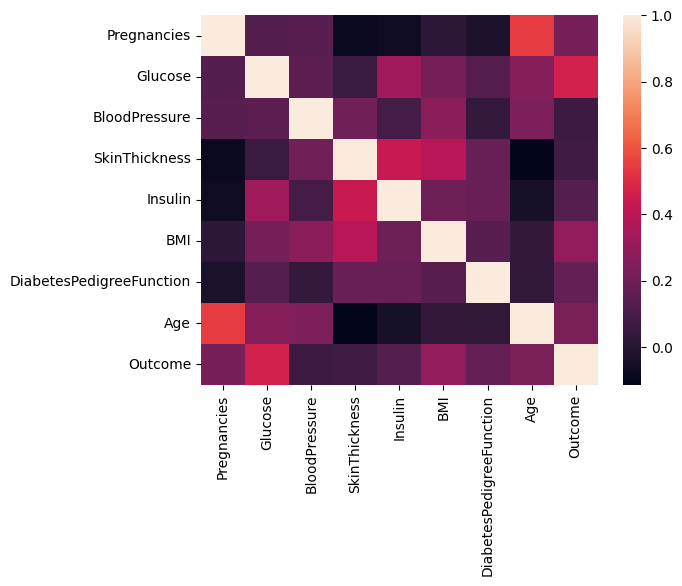

In [20]:
sns.heatmap(df.corr())

In [25]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [33]:
y = df['Outcome'].reshape(1,2)
X = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']

AttributeError: 'Series' object has no attribute 'reshape'

In [31]:
model = xgb.XGBRegressor()
model.fit(X, y.reshape(2,1))

AttributeError: 'Series' object has no attribute 'reshape'

In [34]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



In [35]:
X = df.drop("Outcome", axis=1)  # Features
y = df["Outcome"]               # Target


In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')  # Disable label encoder warning
model.fit(X_train, y_train)

C:\Users\Rudra\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:183: UserWarning: [23:18:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [38]:
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Classification report
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7207792207792207
Confusion Matrix:
 [[72 27]
 [16 39]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.73      0.77        99
           1       0.59      0.71      0.64        55

    accuracy                           0.72       154
   macro avg       0.70      0.72      0.71       154
weighted avg       0.74      0.72      0.73       154



## 1. Standard SHAP Values

In [41]:
# Create TreeExplainer and compute SHAP values
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)


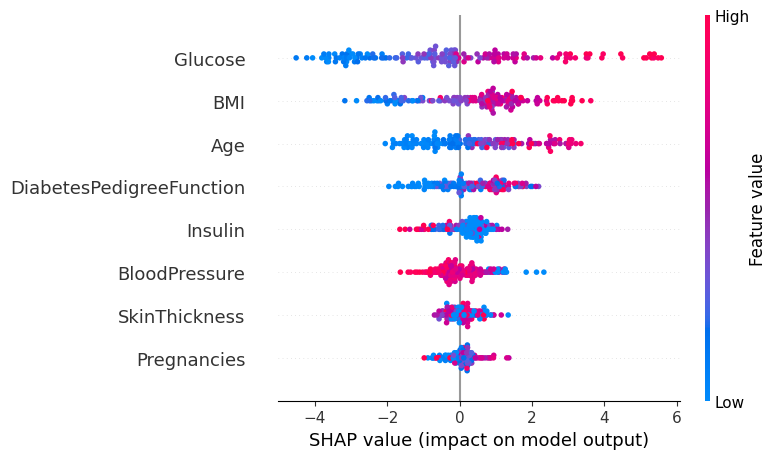

In [42]:
shap.summary_plot(shap_values, X_test)


In [43]:
# Force plot for first prediction
shap.plots.force(shap_values[0])


In [44]:
shap.plots.force(shap_values[:100])  # First 100 predictions


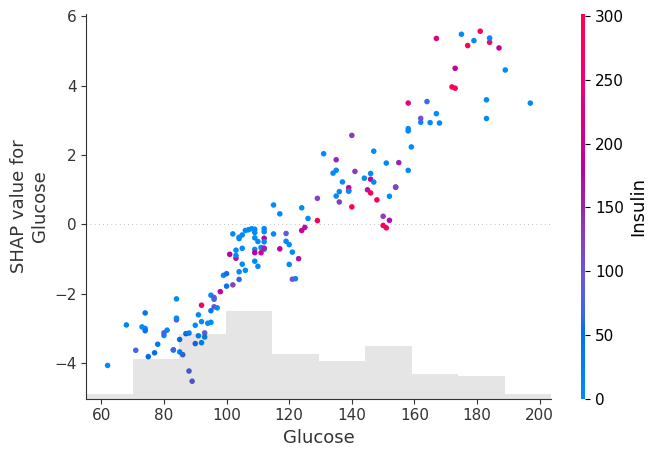

In [45]:
shap.plots.scatter(shap_values[:, "Glucose"], color=shap_values)


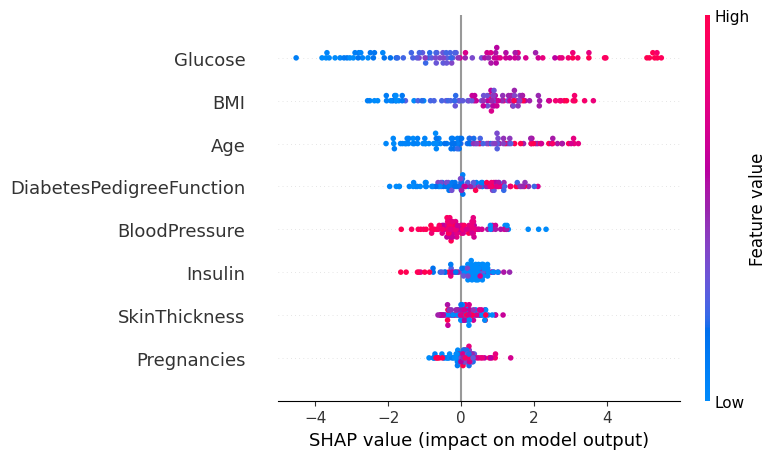

In [46]:
shap_values_sample = explainer(X_test.sample(100, random_state=42))
shap.summary_plot(shap_values_sample, X_test.sample(100, random_state=42))


Where i learn all of this : https://youtu.be/L8_sVRhBDLU?si=38LHAYAQJdDZCA1b